Esta versión de random forest es para el archivo de datos final a 26/02/2026, con la implementación de lag features.

In [1]:
# 0. Importar librerias
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
# 1. Cargar los datos ya procesados
df = pd.read_excel('datos.xlsx', header=0)
# Media de temperatura y humedad de las últimas 72 horas
# Esto le dice al modelo si el terreno viene "calentándose" días atrás
df['temp_media_3d'] = df['temperature_2m (°C)'].rolling(window=72).mean()
df['hum_media_3d'] = df['relative_humidity_2m (%)'].rolling(window=72).mean()

# Variación de presión en las últimas 6 horas (Detección de frentes)
df['delta_presion_6h'] = df['surface_pressure (hPa)'].diff(6)

df=df.dropna(axis=0)

In [3]:
print(df)

                     time  temperature_2m (°C)  relative_humidity_2m (%)  \
71    2017-01-06 23:00:00                  8.3                        95   
72    2017-01-07 00:00:00                  7.9                        96   
73    2017-01-07 01:00:00                  7.1                        97   
74    2017-01-07 02:00:00                  7.0                        97   
75    2017-01-07 03:00:00                  6.9                        97   
...                   ...                  ...                       ...   
70051 2024-12-31 19:00:00                  9.4                        77   
70052 2024-12-31 20:00:00                  8.0                        83   
70053 2024-12-31 21:00:00                  7.4                        87   
70054 2024-12-31 22:00:00                  6.6                        88   
70055 2024-12-31 23:00:00                  5.9                        89   

       surface_pressure (hPa)  wind_speed_10m (km/h)  wind_direction_10m (°)  \
71     

In [4]:
# 2. Selección de variables (X) y objetivo (y)
# Quitamos 'time' porque no es un número y 'incendio' porque es lo que queremos predecir
X = df.drop(columns=['time', 'incendio'])
y = df['incendio']

In [13]:
# 3. División en entrenamiento y prueba (80% tren, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)
original_column_names = list(X_train.columns)


Fitting 3 folds for each of 18 candidates, totalling 54 fits
Mejores parámetros para recall: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Mejores parámetros para f1: {'svc__C': 10, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}


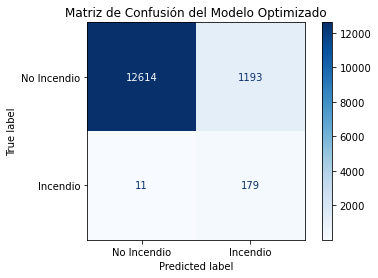

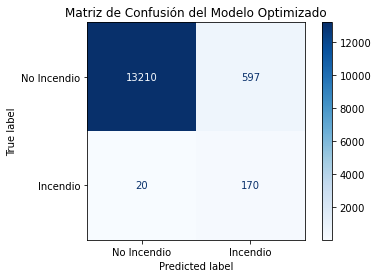

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

param_grid = {
    'svc__C': [1, 5, 10],
    'svc__class_weight': ['balanced'],
    'svc__kernel': ['linear','rbf', 'poly'] ,
    'svc__gamma': ['scale', 'auto']
}

# Para optimizar Recall
grid_recall = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='recall',
    verbose=2,
    n_jobs=-1
)

# Para optimizar F1-score
grid_f1 = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    verbose=2,
    n_jobs=-1
)

grid_recall.fit(X_train, Y_train)

print(f"Mejores parámetros para recall: {grid_recall.best_params_}")

grid_f1.fit(X_train, Y_train)

print(f"Mejores parámetros para f1: {grid_f1.best_params_}")

Y_pred_recall =grid_recall.best_estimator_.predict(X_test)

Y_pred_f1 =grid_f1.best_estimator_.predict(X_test)

# Crear la matriz
cm = confusion_matrix(Y_test, Y_pred_recall)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Incendio', 'Incendio'])

# Dibujar
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión del Modelo Optimizado")
plt.show()

# Crear la matriz
cm = confusion_matrix(Y_test, Y_pred_f1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Incendio', 'Incendio'])

# Dibujar
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión del Modelo Optimizado")
plt.show()

In [7]:
# Crear la matriz
cm = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Incendio', 'Incendio'])

# Dibujar
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión del Modelo Optimizado")
plt.show()

NameError: name 'y_test' is not defined

Index([48687, 48688, 48689, 48690, 48691, 48692, 48693, 48694, 48695, 48696,
       48697, 48698, 48699, 48700, 48701, 48702, 48703, 48704, 48705, 48706,
       48707, 48708, 48709, 48710, 48711, 48712, 48713, 48714, 48715, 48716,
       48717, 48718, 48719, 48720, 48721, 48722, 48723, 48724, 48725, 48726,
       48727, 48728, 48729, 48730, 48731, 48732, 48733, 48734, 48735, 48736,
       48737, 48738, 48739, 48740, 48741, 48742, 48743, 48744, 48745, 48746,
       48747, 48748, 48749, 48750, 48751, 48752, 48753, 48754, 48755, 48756,
       48757, 48758, 48759, 48760, 48761, 48762, 48763, 48764, 48765, 48766,
       48767],
      dtype='int64')


C:\Users\silvi\AppData\Local\Temp/ipykernel_5336/2661332576.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_incendio_test['fecha'] = df.loc[df_incendio_test.index, df.columns[0]]


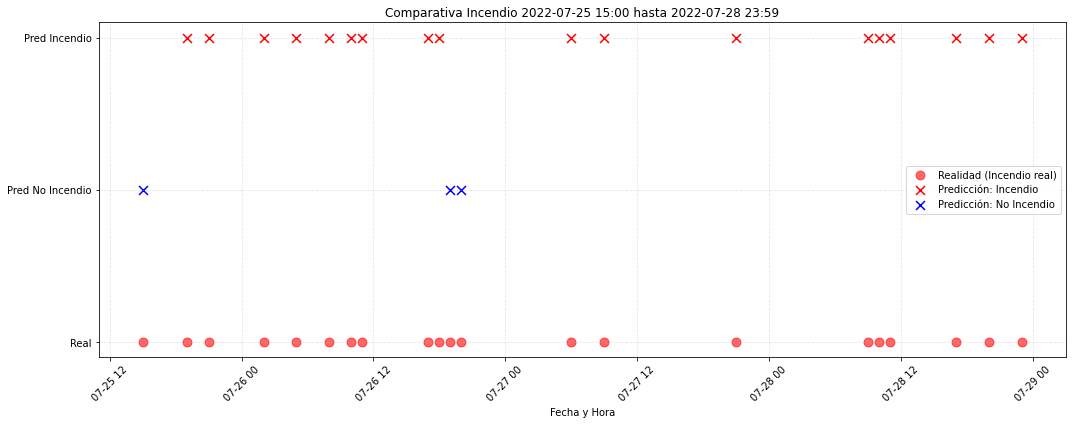

Se han detectado 18 horas del incendio de 21 horas. 


In [8]:
# 1. Buscamos los índices (los números de la izquierda) que corresponden a esas fechas
mask_incendio = (df.iloc[:, 0] >= "2022-07-25 15:00") & (df.iloc[:, 0] <= "2022-07-28 23:59")
indices_incendio = df[mask_incendio].index

print(indices_incendio)
# 2. Creamos un DataFrame de resultados uniendo y_test e y_pred_opt
# Importante: X_test conserva el índice original (ej: 71, 72...)
df_resultados = pd.DataFrame({
    'real': Y_test,
    'prediccion': Y_pred_f1
}, index=Y_test.index)

df_resultados
# 3. Filtramos df_resultados usando solo los índices que encontramos en el paso 1
# Esto selecciona solo las filas del incendio que cayeron en tu set de TEST
df_incendio_test = df_resultados.loc[df_resultados.index.isin(indices_incendio)]

df_incendio_test

# 4. Recuperamos las fechas para el eje X
df_incendio_test['fecha'] = df.loc[df_incendio_test.index, df.columns[0]]
df_incendio_test = df_incendio_test.sort_values('fecha')
 
df_incendio_test
# --- Visualización ---
plt.figure(figsize=(15, 6))

# --- REALIDAD: siempre abajo en rojo ---
plt.scatter(
    df_incendio_test['fecha'], 
    [0]*len(df_incendio_test),   # todos abajo
    color='red', 
    label='Realidad (Incendio real)', 
    s=80, 
    alpha=0.6
)

# --- PREDICCIONES ---
# Predicción = 1 (Incendio) -> cruces rojas arriba
pred_si = df_incendio_test[df_incendio_test['prediccion'] == 1]
plt.scatter(
    pred_si['fecha'], 
    [1]*len(pred_si), 
    color='red', 
    marker='x', 
    label='Predicción: Incendio', 
    s=80
)

# Predicción = 0 (No incendio) -> cruces azules a otra altura
pred_no = df_incendio_test[df_incendio_test['prediccion'] == 0]
plt.scatter(
    pred_no['fecha'], 
    [0.5]*len(pred_no),  # altura intermedia
    color='blue', 
    marker='x', 
    label='Predicción: No Incendio', 
    s=80
)

# Ejes y estilo
plt.yticks([0, 0.5, 1], ['Real', 'Pred No Incendio', 'Pred Incendio'])
plt.title('Comparativa Incendio 2022-07-25 15:00 hasta 2022-07-28 23:59')
plt.xlabel('Fecha y Hora')
plt.grid(True, axis='both', linestyle='--', alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Finalmente, contamos cuantas horas de incendio predice bien

total_incendios_predichos = df_incendio_test['prediccion'].sum()

print(f'Se han detectado {total_incendios_predichos} horas del incendio de {len(df_incendio_test)} horas. ' )

In [15]:
from sklearn.inspection import permutation_importance

X_test_df = pd.DataFrame(X_test, columns=original_column_names)

result = permutation_importance(
    grid_f1.best_estimator_,
    X_test_df,
    Y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importancia = pd.DataFrame({
    'Variable': original_column_names,
    'Importancia': result.importances_mean
}).sort_values(by='Importancia', ascending=False)

print(importancia)

                    Variable  Importancia
9                  temp_t-24     0.065385
5     wind_speed_100m (km/h)     0.038180
2     surface_pressure (hPa)     0.018861
1   relative_humidity_2m (%)     0.012474
8                   temp_t-1     0.007930
15              hum_media_3d     0.001386
16          delta_presion_6h     0.001272
13               presion_t-2     0.000800
11                  hum_t-24     0.000443
14             temp_media_3d     0.000372
6    wind_direction_100m (°)    -0.000357
10                   hum_t-1    -0.001086
3      wind_speed_10m (km/h)    -0.003258
4     wind_direction_10m (°)    -0.003972
0        temperature_2m (°C)    -0.006344
7      wind_gusts_10m (km/h)    -0.007102
12               presion_t-1    -0.010474


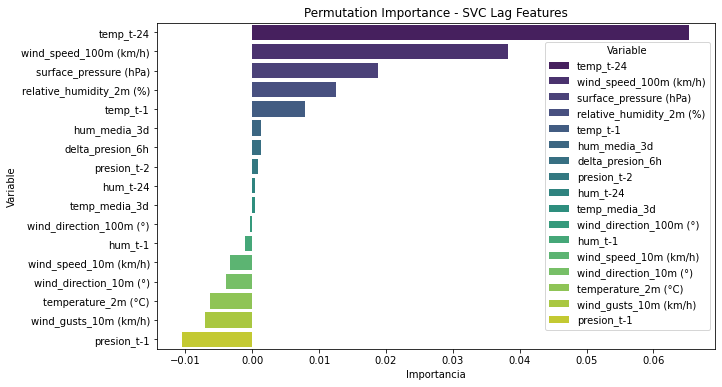

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x='Importancia', y='Variable', data=importancia, hue='Variable',
    dodge=False,
    palette='viridis')
plt.title("Permutation Importance - SVC Lag Features")
plt.show()

In [19]:
import joblib

joblib.dump(grid_f1.best_estimator_, 'modelo_svc_lag.pkl')

['modelo_svc_lag.pkl']